In [2]:
import glob
import json
import os
import pandas as pd
import numpy as np
from pathlib import Path
import jinja2
from IPython.display import display, HTML


In [3]:
def set_project_root(marker="main.py"):
    """
    Finds the project root by searching upwards for a specific marker
    and sets the current working directory.
    """
    current_dir = Path.cwd()

    # Iterate through the current directory and all its parents
    for path in [current_dir, *current_dir.parents]:
        if (path / marker).exists():
            os.chdir(path)
            print(f"Working directory set to: {path}")
            return path

    print(f"Marker '{marker}' not found. Working directory remains: {current_dir}")
    return current_dir

# Execute the function
set_project_root()

Working directory set to: /home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output


PosixPath('/home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output')

In [4]:
def find_failing_queries_per_template(file_path):
    """
    Counts the number of failed queries per template in a JSON file.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        dict: A dictionary mapping template names to their failure counts.
    """
    failure_counts = {}

    with open(file_path, 'r') as file:
        data = json.load(file)

    for entry in data:
        if "error" in entry:
            # Safely navigate the nested dictionary
            template = entry.get("sequenceElement", {}).get("template")

            if template:
                # Initialize to 0 if template is new, then add 1
                failure_counts[template] = failure_counts.get(template, 0) + 1

    return dict(sorted(failure_counts.items()))


def compare_failures_across_files(directory_path):
    """
    Reads all .json files in a directory, extracts failure counts,
    and returns a pandas DataFrame for comparison.
    """
    all_results = {}

    # Locate all JSON files in the target directory
    file_pattern = os.path.join(directory_path, '*.json')
    json_files = glob.glob(file_pattern)

    for file_path in json_files:
        file_name = os.path.basename(file_path)
        # Extract failure counts for the current file
        counts = find_failing_queries_per_template(file_path)
        all_results[file_name] = counts

    # Convert the nested dictionary to a DataFrame
    # This automatically aligns the templates (rows) and files (columns)
    df = pd.DataFrame(all_results)

    # Replace NaN values with 0 and convert to integers
    df = df.fillna(0).astype(int)

    # Sort the index (templates) alphabetically
    df = df.sort_index()

    return df

def find_failing_queries(file_path, target_template):
    """
    Extracts failing queries for a specific template from a JSON file.

    Args:
        file_path (str): The path to the JSON file.
        target_template (str): The template name to filter by (e.g., 'interactive-discover-8').

    Returns:
        list: A list of dictionaries representing the failing queries.
    """
    # Load the JSON data
    with open(file_path, 'r') as file:
        data = json.load(file)

    failing_queries = []

    # Iterate through entries and filter
    for entry in data:
        if "error" in entry:
            sequence_element = entry.get("sequenceElement", {})
            template = sequence_element.get("template")

            if template == target_template:
                # Remove the clutter
                entry.pop("sequenceInstantiationCounts")
                failing_queries.append(entry)

    return failing_queries


In [5]:
failing_queries_all_runs = compare_failures_across_files("data")
failing_queries_all_runs

,query-results-raw-cache-n-b-s.json,query-results-raw-query-cache-estimate-n-b-m.json,query-results-raw-cache-l.json,query-results-raw-cache-n-b-m.json,query-results-raw-cache-n-b-l.json,query-results-raw-default-n-b.json,query-results-raw-query-cache-estimate-n-b-l.json,query-results-raw-default.json,query-results-raw-query-cache-estimate-n-b-s.json,query-results-raw-cache-s.json,query-results-raw-query-cache-n-b-l.json,query-results-raw-query-cache-n-b-s.json,query-results-raw-cache-m.json,query-results-raw-query-cache-n-b-m.json
interactive-discover-1,0,0,5,2,1,1,0,3,3,2,0,1,4,1
interactive-discover-2,3,3,4,0,2,4,7,4,2,3,0,4,2,0
interactive-discover-3,2,2,4,4,1,6,0,4,2,8,1,4,4,1
interactive-discover-4,21,23,21,20,20,21,21,21,20,20,20,22,23,22
interactive-discover-5,91,91,95,91,90,91,90,90,90,92,92,90,90,90
interactive-discover-6,68,68,76,69,71,70,69,70,69,71,69,70,71,71
interactive-discover-7,100,100,99,100,101,100,100,99,100,100,101,100,101,101
interactive-discover-8,31,126,15,30,30,10,131,10,126,14,71,74,16,70
interactive-short-1,2,3,2,2,2,1,1,0,0,5,1,1,3,2
interactive-short-2,100,100,100,100,100,100,100,100,100,99,100,100,100,100


In [6]:
# Investigate large number of errors with estimate cache on interactive-discover-8
failing_discover_8_cache_estimate_n_b_l = find_failing_queries("data/query-results-raw-query-cache-estimate-n-b-l.json", "interactive-discover-8")
failing_discover_8_cache_estimate_n_b_l

[{'name': 'sequence_0',
  'id': '9',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 185040,
  'timestamps': [],
  'httpRequests': 665,
  '@comunica/persistent-cache-manager:sourceStateQuerySource': '{"hits":10,"misses":571,"evictions":2528,"evictionsCalculatedSize":429484,"evictionPercentage":122.70971428571428}',
  'error': 'Unexpected "!" at position 0 in state STOP',
  'user': {'user': 'http://solidbench-server:3000/pods/00000000000000000933/profile/card#me',
   'transitionProbability': 0.09954255358650524},
  'sequenceLength': 28,
  'sequenceElement': {'session': {'task': 'Messages Person',
    'sessionLength': 16,
    'sessionId': 3},
   'template': 'interactive-discover-8',
   'nOpenSessions': 1,
   'refinementMetadata': {}}},
 {'name': 'sequence_0',
  'id': '9',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 185097,
  'timestamps': [],
  'httpRequests': 775,
  '@comunica/persistent-cache-manager:sourceStateQuerySource': '{"hits":

In [7]:
# Compare to failures with default
failing_discover_8_default= find_failing_queries("data/query-results-raw-default.json",
                                                               "interactive-discover-8")
failing_discover_8_default


[{'name': 'sequence_7',
  'id': '26',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 201029,
  'timestamps': [],
  'httpRequests': 137,
  'error': 'Unexpected "!" at position 0 in state STOP',
  'user': {'user': 'http://solidbench-server:3000/pods/00000021990232556027/profile/card#me',
   'transitionProbability': 0.11674512952701303},
  'sequenceLength': 21,
  'sequenceElement': {'session': {'task': 'Attributes Person',
    'sessionLength': 7,
    'sessionId': 5},
   'template': 'interactive-discover-8',
   'nOpenSessions': 2,
   'refinementMetadata': {'patternIds': [6, 7, 4, 0]}}},
 {'name': 'sequence_7',
  'id': '26',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 205241,
  'timestamps': [],
  'httpRequests': 117,
  'error': 'Unexpected "!" at position 0 in state STOP',
  'user': {'user': 'http://solidbench-server:3000/pods/00000021990232556027/profile/card#me',
   'transitionProbability': 0.11674512952701303},
  'sequenceLength': 21,

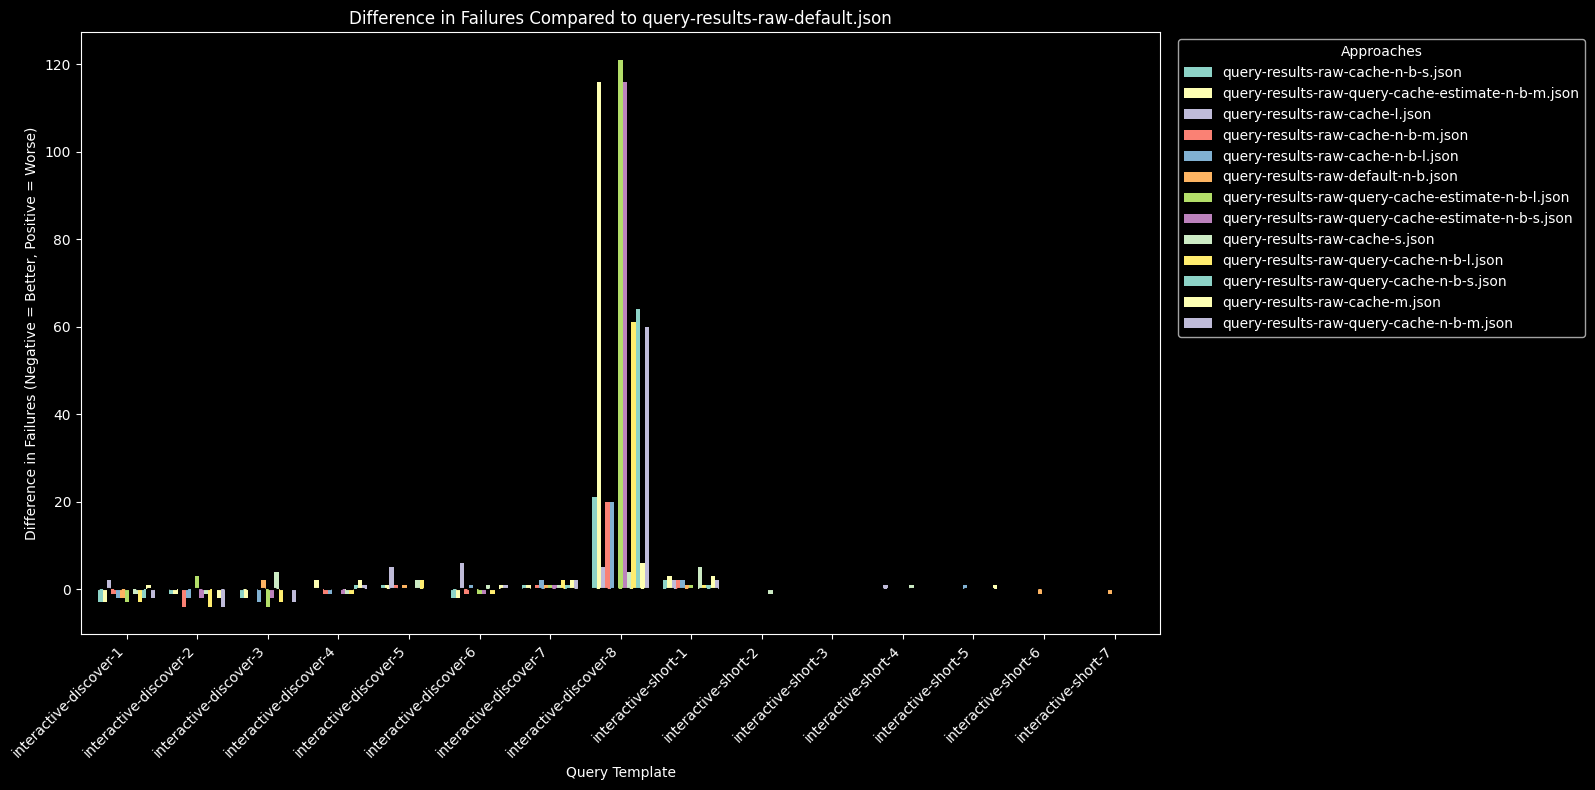

In [8]:
from matplotlib import pyplot as plt

def plot_baseline_differences(df, baseline_column):
    """
    Plots the difference in failure counts between various approaches and a baseline
    using a vertical grouped bar chart.
    """
    if baseline_column not in df.columns:
        raise ValueError(f"Baseline '{baseline_column}' not found.")

    # Calculate the difference from the baseline
    df_diff = df.drop(columns=[baseline_column]).subtract(df[baseline_column], axis=0)

    # Create a vertical grouped bar chart with a wider figure size
    fig, ax = plt.subplots(figsize=(16, 8))
    df_diff.plot(kind='bar', ax=ax, width=0.8)

    # Add a horizontal line at 0 to mark the baseline
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Formatting
    ax.set_title(f'Difference in Failures Compared to {baseline_column}')
    ax.set_ylabel('Difference in Failures (Negative = Better, Positive = Worse)')
    ax.set_xlabel('Query Template')

    # Rotate x-axis labels to ensure readability
    plt.xticks(rotation=45, ha='right')

    # Place legend outside the plot area
    ax.legend(title='Approaches', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_baseline_differences(failing_queries_all_runs, "query-results-raw-default.json")

In [20]:
# Get the per template execution time and hit rate
import os
import json
from typing import Literal
import pandas as pd
import numpy as np
from IPython.display import HTML, display

def generate_comparison_dfs_pooled(files, filterMode: Literal["refinement", "non-refinement"]):
    """
    Parses result files, pools variance across specific query instantiations
    identified by template, name, and id, and generates a DataFrame for each cache type.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        records = []
        for entry in data:
            refinement_metadata = entry.get("sequenceElement").get("refinementMetadata").get("patternIds")
            if refinement_metadata and filterMode == "refinement":
                continue
            if not refinement_metadata and filterMode == 'non-refinement':
                continue

            template = entry.get("sequenceElement", {}).get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                        entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    total = hits + cache_stats.get("misses", 0)
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            # Ensure all composite keys exist before appending
            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000,
                    'hit_rate': hit_rate
                })

        if not records:
            continue

        df_records = pd.DataFrame(records)
        # Calculate variance and mean per exact instantiation (template + name + id)
        inst_stats = df_records.groupby(['template', 'name', 'id']).agg(
            n=('time_s', 'count'),
            var_time=('time_s', 'var'),
            mean_time=('time_s', 'mean'),
            mean_hr=('hit_rate', 'mean')
        ).reset_index()

        inst_stats['var_time'] = inst_stats['var_time'].fillna(0)

        # 3. Pool the metrics up to the template level
        def pool_metrics(group):
            total_weight = (group['n'] - 1).sum()
            if total_weight > 0:
                pooled_var = ((group['n'] - 1) * group['var_time']).sum() / total_weight
            else:
                pooled_var = 0.0

            return pd.Series({
                'Avg Time (s)': group['mean_time'].mean(),
                'Std Time (s)': np.sqrt(pooled_var),
                'Avg Hit Rate': group['mean_hr'].mean()
            })

        template_metrics = inst_stats.groupby('template').apply(pool_metrics, include_groups=False).to_dict('index')
        all_results[label] = template_metrics

    # 4. Group by cache type
    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results.get(algo, {}).get(tmpl, {}).get(metric, np.nan)
                             for tmpl in all_results.get(algo, {})}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Std Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def generate_comparison_dfs(files):
    """
    Parses result files and generates a separate DataFrame for each cache type,
    comparing its sizes against the default baselines.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        template_data = {}
        for entry in data:
            template = entry.get("sequenceElement", {}).get("template")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState")
            if not cache_str:
                cache_str = entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    misses = cache_stats.get("misses", 0)
                    total = hits + misses
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            if template and exec_time is not None:
                if template not in template_data:
                    template_data[template] = {'times': [], 'hit_rates': []}
                template_data[template]['times'].append(exec_time)
                if not np.isnan(hit_rate):
                    template_data[template]['hit_rates'].append(hit_rate)

        avg_metrics = {}
        for tmpl, metrics in template_data.items():
            avg_time = (sum(metrics['times']) / len(metrics['times'])) / 1000
            avg_hr = sum(metrics['hit_rates']) / len(metrics['hit_rates']) if metrics['hit_rates'] else np.nan
            avg_metrics[tmpl] = {'Avg Time (s)': avg_time, 'Avg Hit Rate': avg_hr}

        all_results[label] = avg_metrics

    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue

        # Extract cache type assuming format: {cache_type}-{size}
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    # Create a DataFrame for each cache type
    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        # Sort labels by size: -s, -m, -l
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results[algo][tmpl].get(metric, np.nan) for tmpl in all_results[algo]}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def display_comparison_dfs(dfs_dict):
    """
    Iterates through the dictionary and displays each DataFrame
    as an HTML table with a clear heading.
    """
    for cache_type, df in dfs_dict.items():
        # Print a clear heading for the cache type
        display(HTML(f"<h3>Cache Type: {cache_type.upper()}</h3>"))

        # Display the actual DataFrame
        display(df)

files = glob.glob("data/*.json")
df_avg_times = generate_comparison_dfs_pooled(files, "refinement")
display_comparison_dfs(df_avg_times)

default                            default-n-b  \
                       Avg Time (s) Std Time (s) Avg Hit Rate Avg Time (s)   
interactive-discover-1     5.213408    22.748963          NaN     4.019238   
interactive-discover-2     8.237142    29.605182          NaN     8.320167   
interactive-discover-3    11.203236    34.051664          NaN    13.283182   
interactive-discover-4     6.762689    22.174566          NaN     7.939211   
interactive-discover-5     1.278067     0.326962          NaN     3.291689   
interactive-discover-6    91.958170    22.240500          NaN    95.602130   
interactive-discover-7   108.140908    14.896226          NaN   109.107808   
interactive-discover-8    11.219845     3.787402          NaN    11.414109   
interactive-short-1        1.591840     0.913488          NaN     3.615360   
interactive-short-2      185.623220     1.533744          NaN   185.488640   
interactive-short-3      149.148400     6.399999          NaN   147.257589   
interactive-short-4        0.394036     1.930612          NaN     0.223564   
interactive-short-5        0.494680     0.446312          NaN     0.591030   
interactive-short-6      185.141450     0.391153          NaN   184.403743   
interactive-short-7      172.902543     1.882057          NaN   172.191936   

                                                      cache-s               \
                       Std Time (s) Avg Hit Rate Avg Time (s) Std Time (s)   
interactive-discover-1    16.659696          NaN     3.221185    16.078040   
interactive-discover-2    29.345750          NaN     7.534467    28.123074   
interactive-discover-3    39.991673          NaN    17.148736    46.844206   
interactive-discover-4    27.021455          NaN     4.146744     8.957351   
interactive-discover-5    19.294469          NaN     4.697133    20.932468   
interactive-discover-6    11.694274          NaN    95.375860    18.083909   
interactive-discover-7     3.052329          NaN   106.882325    29.753662   
interactive-discover-8     6.111160          NaN    17.345464    31.200363   
interactive-short-1       18.149231          NaN    10.776970    35.356198   
interactive-short-2        1.500773          NaN   182.401430    21.203705   
interactive-short-3        4.153194          NaN   148.346556    20.791329   
interactive-short-4        0.612361          NaN     0.304114     1.539849   
interactive-short-5        0.747557          NaN     0.778280     2.157225   
interactive-short-6        8.391718          NaN   183.757614    15.231629   
interactive-short-7       10.910852          NaN   171.620993    17.900896   

                                         cache-m                            \
                       Avg Hit Rate Avg Time (s) Std Time (s) Avg Hit Rate   
interactive-discover-1     0.444868     8.675600    31.709408     0.553493   
interactive-discover-2     0.268584     7.339475    24.552484     0.350497   
interactive-discover-3     0.161941     8.855255    27.718604     0.179872   
interactive-discover-4     0.235197    10.231389    31.905377     0.244296   
interactive-discover-5     0.452138     1.595656     1.752117     0.539277   
interactive-discover-6     0.157743    90.191150    21.755089     0.223005   
interactive-discover-7     0.250485   108.430217    25.737807     0.265731   
interactive-discover-8     0.131956    11.736618    12.337309     0.190511   
interactive-short-1        0.345839     8.018030    32.149860     0.356780   
interactive-short-2        0.095790   174.456270    32.167389     0.179698   
interactive-short-3        0.355861   148.049400    32.411151     0.403089   
interactive-short-4        0.866667     0.701279     4.266716     0.868869   
interactive-short-5        0.442037     0.742800     2.189796     0.466057   
interactive-short-6        0.132171   184.150043    14.680536     0.208890   
interactive-short-7        0.257081   175.195171    14.158237     0.313752   

                            cache-l            

default                            default-n-b  \
                       Avg Time (s) Std Time (s) Avg Hit Rate Avg Time (s)   
interactive-discover-1     5.213408    22.748963          NaN     4.019238   
interactive-discover-2     8.237142    29.605182          NaN     8.320167   
interactive-discover-3    11.203236    34.051664          NaN    13.283182   
interactive-discover-4     6.762689    22.174566          NaN     7.939211   
interactive-discover-5     1.278067     0.326962          NaN     3.291689   
interactive-discover-6    91.958170    22.240500          NaN    95.602130   
interactive-discover-7   108.140908    14.896226          NaN   109.107808   
interactive-discover-8    11.219845     3.787402          NaN    11.414109   
interactive-short-1        1.591840     0.913488          NaN     3.615360   
interactive-short-2      185.623220     1.533744          NaN   185.488640   
interactive-short-3      149.148400     6.399999          NaN   147.257589   
interactive-short-4        0.394036     1.930612          NaN     0.223564   
interactive-short-5        0.494680     0.446312          NaN     0.591030   
interactive-short-6      185.141450     0.391153          NaN   184.403743   
interactive-short-7      172.902543     1.882057          NaN   172.191936   

                                                  cache-n-b-s               \
                       Std Time (s) Avg Hit Rate Avg Time (s) Std Time (s)   
interactive-discover-1    16.659696          NaN     1.407162     2.190238   
interactive-discover-2    29.345750          NaN     5.549925    24.544524   
interactive-discover-3    39.991673          NaN     6.376527    24.702212   
interactive-discover-4    27.021455          NaN     3.134178    11.553075   
interactive-discover-5    19.294469          NaN     3.344478    19.235978   
interactive-discover-6    11.694274          NaN    89.951570    23.666610   
interactive-discover-7     3.052329          NaN   107.763442    17.849294   
interactive-discover-8     6.111160          NaN     2.108591    11.131078   
interactive-short-1       18.149231          NaN     3.601680    18.267459   
interactive-short-2        1.500773          NaN   183.487450    16.180084   
interactive-short-3        4.153194          NaN   143.946789     0.039962   
interactive-short-4        0.612361          NaN     0.924800     6.777875   
interactive-short-5        0.747557          NaN     0.999780     4.019584   
interactive-short-6        8.391718          NaN   183.953500    14.465033   
interactive-short-7       10.910852          NaN   170.287100    14.801332   

                                     cache-n-b-m                            \
                       Avg Hit Rate Avg Time (s) Std Time (s) Avg Hit Rate   
interactive-discover-1     0.464922     5.342500    24.063726     0.448140   
interactive-discover-2     0.251847     1.509975     1.318994     0.221490   
interactive-discover-3     0.126814     7.894600    28.784991     0.113182   
interactive-discover-4     0.229544     2.810656    13.406446     0.236139   
interactive-discover-5     0.454525     1.606667     5.365961     0.475704   
interactive-discover-6     0.137624    91.413060    18.220458     0.151178   
interactive-discover-7     0.254359   108.477750     1.360167     0.219764   
interactive-discover-8     0.142908     1.436836     4.059033     0.137297   
interactive-short-1        0.304890     4.575900    20.674781     0.305207   
interactive-short-2        0.061916   182.494500    22.334213     0.056112   
interactive-short-3        0.267370   140.317878    23.263993     0.280890   
interactive-short-4        0.800500     0.497014     2.960993     0.794762   
interactive-short-5        0.427739     0.924040     3.255599     0.426320   
interactive-short-6        0.135502   183.725043    13.374712     0.103062   
interactive-short-7        0.251545   167.057500    22.248488     0.248838   

                        cache-n-b-l            

default                            default-n-b  \
                       Avg Time (s) Std Time (s) Avg Hit Rate Avg Time (s)   
interactive-discover-1     5.213408    22.748963          NaN     4.019238   
interactive-discover-2     8.237142    29.605182          NaN     8.320167   
interactive-discover-3    11.203236    34.051664          NaN    13.283182   
interactive-discover-4     6.762689    22.174566          NaN     7.939211   
interactive-discover-5     1.278067     0.326962          NaN     3.291689   
interactive-discover-6    91.958170    22.240500          NaN    95.602130   
interactive-discover-7   108.140908    14.896226          NaN   109.107808   
interactive-discover-8    11.219845     3.787402          NaN    11.414109   
interactive-short-1        1.591840     0.913488          NaN     3.615360   
interactive-short-2      185.623220     1.533744          NaN   185.488640   
interactive-short-3      149.148400     6.399999          NaN   147.257589   
interactive-short-4        0.394036     1.930612          NaN     0.223564   
interactive-short-5        0.494680     0.446312          NaN     0.591030   
interactive-short-6      185.141450     0.391153          NaN   184.403743   
interactive-short-7      172.902543     1.882057          NaN   172.191936   

                                                 query-cache-estimate-n-b-s  \
                       Std Time (s) Avg Hit Rate               Avg Time (s)   
interactive-discover-1    16.659696          NaN                   3.887146   
interactive-discover-2    29.345750          NaN                   4.535983   
interactive-discover-3    39.991673          NaN                   6.811500   
interactive-discover-4    27.021455          NaN                   1.996233   
interactive-discover-5    19.294469          NaN                   1.162933   
interactive-discover-6    11.694274          NaN                  86.633030   
interactive-discover-7     3.052329          NaN                 108.542033   
interactive-discover-8     6.111160          NaN                 135.224527   
interactive-short-1       18.149231          NaN                   2.027020   
interactive-short-2        1.500773          NaN                 180.563710   
interactive-short-3        4.153194          NaN                 141.022267   
interactive-short-4        0.612361          NaN                   0.520779   
interactive-short-5        0.747557          NaN                   1.856880   
interactive-short-6        8.391718          NaN                 185.447421   
interactive-short-7       10.910852          NaN                 161.091071   

                                                 query-cache-estimate-n-b-m  \
                       Std Time (s) Avg Hit Rate               Avg Time (s)   
interactive-discover-1    18.391287     0.442556                   1.341662   
interactive-discover-2    16.747474     0.222149                   5.530150   
interactive-discover-3    24.451556     0.144293                   6.451518   
interactive-discover-4     4.202300     0.212448                   6.410844   
interactive-discover-5     1.362639     0.450537                   6.194433   
interactive-discover-6    42.324511     0.156009                  87.467550   
interactive-discover-7     1.743801     0.209361                 106.128783   
interactive-discover-8    41.908510     0.050413                 143.021773   
interactive-short-1        4.292247     0.323947                   4.471930   
interactive-short-2       29.517277     0.072789                 181.125820   
interactive-short-3       19.761799     0.197999                 139.295356   
interactive-short-4        1.648900     0.775651                   0.767357   
interactive-short-5        4.482185     0.421210                   0.738520   
interactive-short-6       11.241530     0.070603                 182.060936   
interactive-short-7       35.372046     0.175240                 161.638021   

             

default                            default-n-b  \
                       Avg Time (s) Std Time (s) Avg Hit Rate Avg Time (s)   
interactive-discover-1     5.213408    22.748963          NaN     4.019238   
interactive-discover-2     8.237142    29.605182          NaN     8.320167   
interactive-discover-3    11.203236    34.051664          NaN    13.283182   
interactive-discover-4     6.762689    22.174566          NaN     7.939211   
interactive-discover-5     1.278067     0.326962          NaN     3.291689   
interactive-discover-6    91.958170    22.240500          NaN    95.602130   
interactive-discover-7   108.140908    14.896226          NaN   109.107808   
interactive-discover-8    11.219845     3.787402          NaN    11.414109   
interactive-short-1        1.591840     0.913488          NaN     3.615360   
interactive-short-2      185.623220     1.533744          NaN   185.488640   
interactive-short-3      149.148400     6.399999          NaN   147.257589   
interactive-short-4        0.394036     1.930612          NaN     0.223564   
interactive-short-5        0.494680     0.446312          NaN     0.591030   
interactive-short-6      185.141450     0.391153          NaN   184.403743   
interactive-short-7      172.902543     1.882057          NaN   172.191936   

                                                 query-cache-n-b-s  \
                       Std Time (s) Avg Hit Rate      Avg Time (s)   
interactive-discover-1    16.659696          NaN          1.784108   
interactive-discover-2    29.345750          NaN          5.413058   
interactive-discover-3    39.991673          NaN          8.211945   
interactive-discover-4    27.021455          NaN          4.395822   
interactive-discover-5    19.294469          NaN          1.043478   
interactive-discover-6    11.694274          NaN         87.493120   
interactive-discover-7     3.052329          NaN        106.839100   
interactive-discover-8     6.111160          NaN         73.687091   
interactive-short-1       18.149231          NaN          4.929470   
interactive-short-2        1.500773          NaN        183.586280   
interactive-short-3        4.153194          NaN        138.866000   
interactive-short-4        0.612361          NaN          0.279136   
interactive-short-5        0.747557          NaN          0.872730   
interactive-short-6        8.391718          NaN        181.101536   
interactive-short-7       10.910852          NaN        166.999379   

                                                 query-cache-n-b-m  \
                       Std Time (s) Avg Hit Rate      Avg Time (s)   
interactive-discover-1     4.712303     0.453154          1.233508   
interactive-discover-2    23.395604     0.286713          2.474075   
interactive-discover-3    29.116805     0.137592          4.693473   
interactive-discover-4    24.918324     0.211532          5.050800   
interactive-discover-5     0.984597     0.464140          1.985167   
interactive-discover-6    39.187680     0.148600         93.113420   
interactive-discover-7    14.904769     0.217539        106.633858   
interactive-discover-8    46.656614     0.117569         69.096864   
interactive-short-1       24.611043     0.334929          5.052670   
interactive-short-2       20.512425     0.069668        176.538790   
interactive-short-3       22.582074     0.225580        143.705100   
interactive-short-4        0.941363     0.830635          0.373493   
interactive-short-5        5.155804     0.424879          0.911350   
interactive-short-6       21.725021     0.108597        180.379000   
interactive-short-7       23.953544     0.212216        164.634807   

                                                 query-cache-n-b-l  \
                       Std Time (s) Avg Hit Rate      Avg Time (s)   
interactive-discover-1     2.217359     0.429490          1.176885   
interactive-discover-2    13.330906     0.325508          2.290917   
interactive-discover-3    16.951087    

In [33]:
import os
import json
import pandas as pd
from typing import Literal

def extract_raw_metrics(files, filterMode: Literal["refinement", "non-refinement", "all"] = "all", target_file: str = None):
    """
    Parses result files and aggregates raw execution times into lists.
    Optionally limits parsing to a single specified file.
    """
    records = []

    if target_file:
        files = [f for f in files if target_file in f]

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        for entry in data:
            seq_element = entry.get("sequenceElement") or {}
            ref_metadata = seq_element.get("refinementMetadata") or {}
            pattern_ids = ref_metadata.get("patternIds")

            if filterMode == "refinement" and pattern_ids:
                continue
            if filterMode == "non-refinement" and not pattern_ids:
                continue

            template = seq_element.get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")

            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'label': label,
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000
                })

    if not records:
        return pd.DataFrame()

    df_records = pd.DataFrame(records)

    raw_times_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    )['time_s'].apply(list).reset_index()

    raw_times_df.rename(columns={'time_s': 'execution_times_s'}, inplace=True)
    raw_times_df['execution_count'] = raw_times_df['execution_times_s'].apply(len)

    return raw_times_df

In [34]:
files = glob.glob("data/*.json")

# Remove column width limits to display full lists
pd.set_option('display.max_colwidth', None)
df_raw = extract_raw_metrics(files, "refinement", target_file="query-results-raw-default.json")

# Display the raw lists for a specific template or cache label
display(df_raw[df_raw["name"] == "sequence_0"])
pd.reset_option('display.max_colwidth')

,label,template,name,id,execution_times_s,execution_count
0,default,interactive-discover-1,sequence_0,22,"[0.654, 0.592, 0.576, 0.591, 19.339, 0.582, 0.623, 0.608, 0.557, 0.517]",10
1,default,interactive-discover-1,sequence_0,34,"[7.651, 9.847, 5.201, 4.638, 88.563, 4.58, 4.824, 4.848, 5.031, 4.794]",10
2,default,interactive-discover-1,sequence_0,7,"[1.031, 0.611, 0.693, 0.747, 0.653, 0.66, 0.746, 0.725, 0.707, 0.645]",10
13,default,interactive-discover-2,sequence_0,16,"[0.965, 0.829, 7.809, 0.903, 0.733, 0.854, 185.122, 0.991, 0.877, 0.886]",10
25,default,interactive-discover-3,sequence_0,21,"[0.347, 0.37, 0.311, 0.288, 0.334, 0.373, 0.298, 0.343, 0.354, 3.128]",10
26,default,interactive-discover-3,sequence_0,3,"[6.332, 134.459, 6.755, 5.837, 5.946, 6.501, 6.841, 185.108, 6.132, 185.053]",10
27,default,interactive-discover-3,sequence_0,31,"[0.611, 0.635, 0.623, 0.616, 0.641, 0.662, 0.641, 0.618, 0.59, 0.644]",10
36,default,interactive-discover-4,sequence_0,33,"[0.957, 0.969, 1.072, 81.653, 0.974, 1.116, 1.01, 0.918, 1.029, 1.06]",10
37,default,interactive-discover-4,sequence_0,4,"[0.196, 0.183, 0.182, 0.209, 0.172, 0.169, 0.222, 0.208, 0.175, 0.211]",10
45,default,interactive-discover-5,sequence_0,20,"[0.362, 0.291, 0.338, 0.805, 0.323, 0.333, 0.564, 0.299, 0.299, 3.01]",10
